# Project 06 - Mini-GPT: Build a Transformer From Scratch

**A self-explanatory Kaggle notebook.** Each code cell is explained in plain English above it.

This is the conceptual peak of the foundations: we open up the transformer - the architecture
behind every modern LLM (GPT, Claude, Llama) - and build its core piece, **self-attention**, in
plain NumPy, then visualise it. We also build a tiny text generator so "predict the next token"
becomes concrete. The full GPU training code (nanoGPT-style) is at the end for Kaggle.

**What you'll learn**
- **Language modelling**: predicting the next token, over and over, is all an LLM does.
- **Self-attention**: how a token "looks at" other tokens - you'll SEE the attention matrix.
- **Causal masking**: why a token must not see the future (so it can generate).

## The scenario
You want to understand how ChatGPT-like models actually work - not as magic, but as code. The
secret is one operation, **attention**, repeated in layers. Build it once by hand and every LLM
you ever use becomes legible.

## Foundations (plain English)
- **Tokens**: text is chopped into pieces (here, single characters) each mapped to an id.
- **Language modelling**: the model predicts the next token given the previous ones. Generating
  text = predict next token, append it, repeat.
- **Self-attention**: for each token, the model forms a **query** and compares it to every other
  token's **key** to decide how much to "pay attention" to each, then mixes their **values**. This
  is how a word gathers context from the rest of the sentence.
- **Causal mask**: when generating, a token may only attend to itself and *earlier* tokens - never
  the future (which it hasn't produced yet).
- **Positional information**: attention has no built-in sense of order, so position is added in.

### Cell 1 - imports and a tiny corpus
We use character-level tokenization: the vocabulary is just the unique characters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

corpus = ("the cat sat on the mat. the cat ran to the man. "
          "the dog sat on the log. the dog ran to the den. ") * 6
chars = sorted(set(corpus))
stoi = {c:i for i,c in enumerate(chars)}; itos = {i:c for c,i in stoi.items()}
print("vocab size:", len(chars), "| chars:", "".join(chars))
print("encoded 'cat' ->", [stoi[c] for c in "cat"])

vocab size: 15 | chars:  .acdeghlmnorst
encoded 'cat' -> [3, 2, 14]


### Cell 2 - self-attention in NumPy
For a sequence of token vectors X, we make **Q**ueries, **K**eys, **V**alues by multiplying by
weight matrices. `scores = Q . K^T` measures how much each token should attend to each other; we
scale, apply the **causal mask** (block the future), softmax into weights, and mix the values.

In [2]:
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True); e = np.exp(x); return e / e.sum(axis=axis, keepdims=True)

word = "attention"                      # we'll attend over the letters of this word
T, d = len(word), 16
rng = np.random.default_rng(0)
X = rng.standard_normal((T, d))         # pretend these are the token embeddings
Wq, Wk, Wv = (rng.standard_normal((d, d))*0.5 for _ in range(3))
Q, K, V = X @ Wq, X @ Wk, X @ Wv

scores = (Q @ K.T) / np.sqrt(d)         # (T, T): token-to-token attention scores
mask = np.triu(np.ones((T, T)), k=1).astype(bool)   # True = "future" positions to block
scores[mask] = -1e9                     # causal mask: can't look ahead
attn = softmax(scores, axis=-1)         # each row sums to 1
out = attn @ V                          # each token = weighted mix of values
print("attention matrix shape:", attn.shape, "| each row sums to 1:", np.allclose(attn.sum(1), 1))

attention matrix shape: (9, 9) | each row sums to 1: True


### Cell 3 - diagram: the causal mask and the attention weights
**Left:** the causal mask - a token (row) may only attend to columns at or before it (the upper
triangle is blocked). **Right:** the resulting attention weights over the letters of "attention".
Notice the upper triangle is exactly 0 - the model literally cannot see the future.

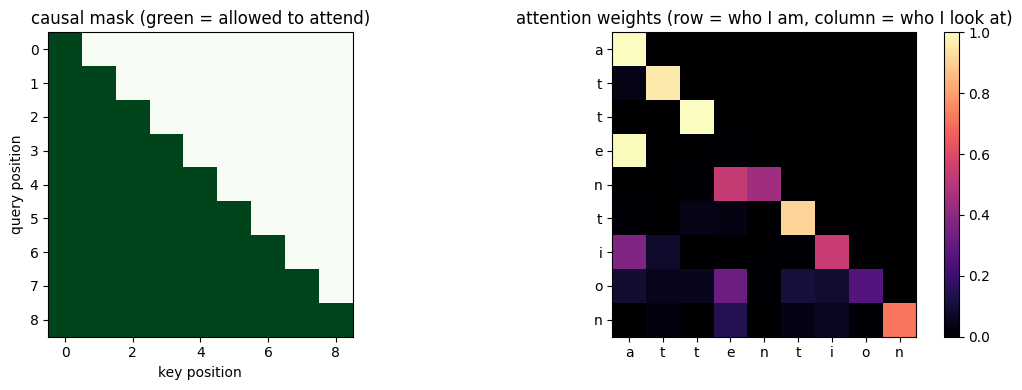

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
allowed = (~mask).astype(float)
ax[0].imshow(allowed, cmap="Greens"); ax[0].set_title("causal mask (green = allowed to attend)")
ax[0].set_xlabel("key position"); ax[0].set_ylabel("query position")
im = ax[1].imshow(attn, cmap="magma")
ax[1].set_xticks(range(T)); ax[1].set_xticklabels(list(word))
ax[1].set_yticks(range(T)); ax[1].set_yticklabels(list(word))
ax[1].set_title("attention weights (row = who I am, column = who I look at)")
fig.colorbar(im, ax=ax[1], fraction=0.046); plt.tight_layout(); plt.show()

### Cell 4 - a tiny language model that actually generates text
To make "next-token prediction" concrete, we build the simplest possible model: a **bigram** - it
learns, for each character, the probability of the next character (with add-one smoothing). Then
we generate by sampling one character at a time. It only has a **1-character memory**, so the
output is babble with local structure - which is exactly why we need transformers that attend
over the *whole* context.

In [4]:
V_ = len(chars)
counts = np.ones((V_, V_))                       # add-one smoothing (no zero probabilities)
for a, b in zip(corpus, corpus[1:]):
    counts[stoi[a], stoi[b]] += 1
P = counts / counts.sum(axis=1, keepdims=True)   # row i = distribution of next char after i

def generate(start="t", n=120, seed=0):
    rng = np.random.default_rng(seed); i = stoi[start]; out = [start]
    for _ in range(n):
        i = rng.choice(V_, p=P[i]); out.append(itos[i])     # sample the next character
    return "".join(out)

print(generate())

the atogg.rn t t the cathe trgcg dog rrsatcde t t then mande o ccat the thran.toghe the.ratos tssaton glsathn th.d thn t 


### Cell 5 - diagram: what the bigram learned
The heatmap shows P(next char | current char). Bright cells are likely transitions (e.g. after a
space, letters like 't' and 'd' are likely because our corpus starts words with them). A
transformer generalises this from "1 char back" to "the whole context".

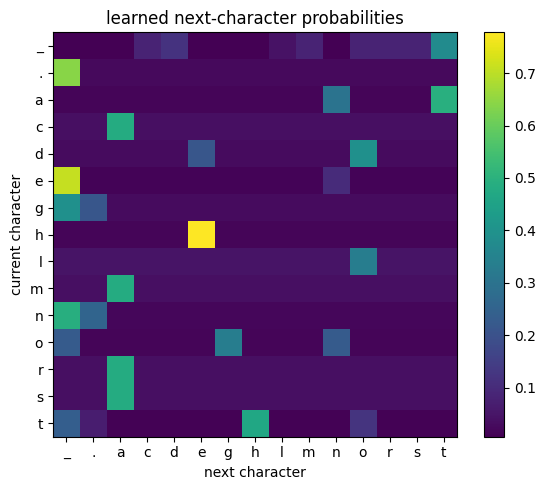

In [5]:
plt.figure(figsize=(6,5))
im = plt.imshow(P, cmap="viridis")
plt.xticks(range(V_), [c if c!=' ' else '_' for c in chars])
plt.yticks(range(V_), [c if c!=' ' else '_' for c in chars])
plt.xlabel("next character"); plt.ylabel("current character")
plt.title("learned next-character probabilities"); plt.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

## The real thing - a GPT you train on a Kaggle GPU
Stack the attention you just built into **blocks** (attention + a small MLP + residual
connections + layer-norm), add token & positional embeddings, and train it to predict the next
token. This is essentially Andrej Karpathy's nanoGPT. Run on a Kaggle Notebook with
**Accelerator = GPU**.

```python
import torch, torch.nn as nn, torch.nn.functional as F

class Block(nn.Module):                      # one transformer decoder block
    def __init__(self, n_embd, n_head, block_size):
        super().__init__()
        self.attn = nn.MultiheadAttention(n_embd, n_head, batch_first=True)
        self.ln1, self.ln2 = nn.LayerNorm(n_embd), nn.LayerNorm(n_embd)
        self.mlp = nn.Sequential(nn.Linear(n_embd, 4*n_embd), nn.GELU(),
                                 nn.Linear(4*n_embd, n_embd))
        self.register_buffer("mask", torch.triu(torch.ones(block_size, block_size), 1).bool())
    def forward(self, x):
        T = x.size(1)
        a,_ = self.attn(self.ln1(x), self.ln1(x), self.ln1(x),
                        attn_mask=self.mask[:T,:T])   # causal mask = no peeking ahead
        x = x + a                                     # residual connection
        x = x + self.mlp(self.ln2(x))
        return x

class MiniGPT(nn.Module):
    def __init__(self, vocab, n_embd=128, n_head=4, n_layer=4, block_size=128):
        super().__init__()
        self.tok = nn.Embedding(vocab, n_embd)          # token embeddings
        self.pos = nn.Embedding(block_size, n_embd)     # positional embeddings
        self.blocks = nn.Sequential(*[Block(n_embd, n_head, block_size) for _ in range(n_layer)])
        self.ln = nn.LayerNorm(n_embd); self.head = nn.Linear(n_embd, vocab)
    def forward(self, idx):
        T = idx.size(1); pos = torch.arange(T, device=idx.device)
        x = self.tok(idx) + self.pos(pos)
        return self.head(self.ln(self.blocks(x)))       # logits over the vocabulary

# training step (data = long stream of token ids; xb,yb are (batch, block_size)):
# logits = model(xb)
# loss = F.cross_entropy(logits.view(-1, vocab), yb.view(-1))
# loss.backward(); opt.step(); opt.zero_grad()
```
Train on TinyShakespeare (a Kaggle dataset), log the loss to W&B, and sample text from
checkpoints to watch it improve. Compare your loss curve to nanoGPT's to sanity-check.

## What just happened (recap)
- An LLM just **predicts the next token**, repeatedly.
- **Self-attention** lets each token gather context from others; you built it in NumPy and saw
  the **attention matrix**.
- The **causal mask** blocks the future (the upper triangle is exactly 0) so the model can
  generate left-to-right.
- A **bigram** with 1-token memory babbles - motivating transformers that attend over the whole
  context. The Kaggle-GPU code stacks attention into a real mini-GPT.

## Scenarios & your turn
- **Attention pattern:** change `word` in Cell 2 and re-plot - the structure stays causal.
- **Bigram limits:** read the generated babble - what's missing is *long-range* context, exactly
  what attention provides.
- **Train for real:** run the nanoGPT code on TinyShakespeare; sample text every few hundred steps.
- **Next:** Projects 07+ use pretrained transformers for RAG, fine-tuning, and agents.

## Mini-glossary
**token** a text piece/id - **language modelling** predict the next token - **self-attention**
mix tokens by learned relevance - **query/key/value** compare (Q,K) to weight values (V) -
**causal mask** block future tokens - **positional embedding** inject word order - **block**
attention + MLP + residual + layer-norm - **sampling/temperature** how randomly you pick the next
token.